# 02. Demand Forecasting

## Goal
Predict demand for store_1 / item_1 and compare simple forecasting approaches on the same time series.

## Models Compared
- Baseline mean-demand model
- Linear Regression
- Random Forest

## Evaluation Focus
The notebook compares models using MAE and RMSE, then visualizes actual versus predicted demand.

## Why It Matters
This step shows whether machine learning improves forecast quality enough to support better downstream inventory decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("../data/retail_sales.csv")
df["date"] = pd.to_datetime(df["date"])

sample = df[(df["store_id"] == "store_1") & (df["item_id"] == "item_1")].copy()
sample = sample.sort_values("date").reset_index(drop=True)

sample["year"] = sample["date"].dt.year
sample["month"] = sample["date"].dt.month
sample["day"] = sample["date"].dt.day
sample["dayofweek"] = sample["date"].dt.dayofweek
sample["weekofyear"] = sample["date"].dt.isocalendar().week.astype(int)

sample.head()

,date,store_id,item_id,sales,price,promo,weekday,month,year,day,dayofweek,weekofyear
0,2019-01-01,store_1,item_1,41,21.30,0,1,1,2019,1,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1,2019,2,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1,2019,3,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1,2019,4,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1,2019,5,5,1


In [3]:
train_size = int(len(sample) * 0.8)

train = sample.iloc[:train_size]
test = sample.iloc[train_size:]

features = ["year", "month", "day", "dayofweek", "weekofyear", "price", "promo"]
target = "sales"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1460
Test size: 366


In [4]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))

mae_baseline = mean_absolute_error(y_test, baseline_pred)
rmse_baseline = mean_squared_error(y_test, baseline_pred) ** 0.5

print("Baseline MAE:", round(mae_baseline, 2))
print("Baseline RMSE:", round(rmse_baseline, 2))

Baseline MAE: 11.73
Baseline RMSE: 15.71


In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = mean_squared_error(y_test, lr_pred) ** 0.5

print("Linear Regression MAE:", round(mae_lr, 2))
print("Linear Regression RMSE:", round(rmse_lr, 2))

Linear Regression MAE: 7.33
Linear Regression RMSE: 9.14


In [6]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = mean_squared_error(y_test, rf_pred) ** 0.5

print("Random Forest MAE:", round(mae_rf, 2))
print("Random Forest RMSE:", round(rmse_rf, 2))

Random Forest MAE: 3.64
Random Forest RMSE: 4.52


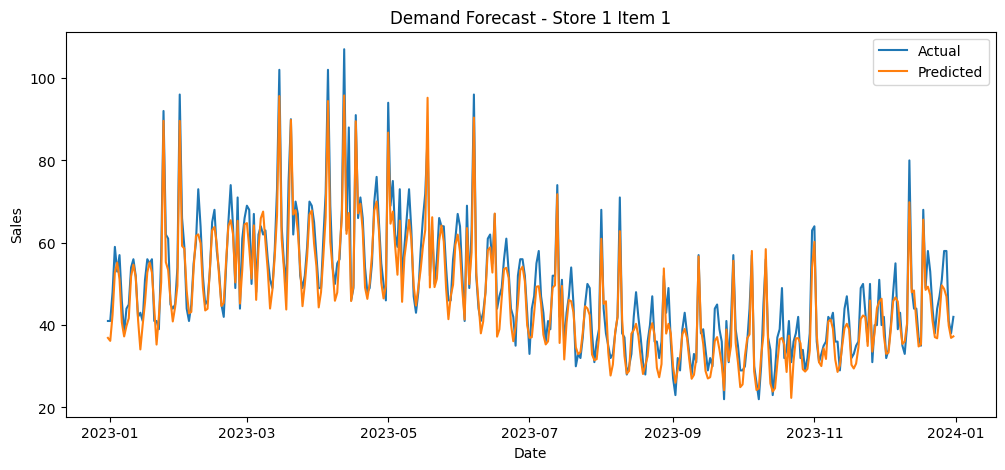

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(test["date"], y_test.values, label="Actual")
plt.plot(test["date"], rf_pred, label="Predicted")
plt.title("Demand Forecast - Store 1 Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [8]:
results = pd.DataFrame({
    "model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [mae_baseline, mae_lr, mae_rf],
    "RMSE": [rmse_baseline, rmse_lr, rmse_rf]
})

results

,model,MAE,RMSE
0,Baseline,11.728745,15.712170
1,Linear Regression,7.331365,9.143919
2,Random Forest,3.642001,4.520608


## Interpretation
- The Random Forest model reduces error compared with both the baseline and Linear Regression models.
- Forecasting helps estimate expected demand and demand variability.
- These estimates can be used directly in inventory policy design.